In [1]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np

In [2]:
login = 5032416307
password = "AuY_Jm0t"
server = "MetaQuotes-Demo"
timeout = 10000
portable = False
if mt5.initialize(login=login, password=password, server=server, timeout=timeout, portable=portable):
    print("Initialization successful")
else:
    print("Initialization not successful")

KeyboardInterrupt: 

In [2]:
path = "C:\\Program Files\\MetaTrader 5\\terminal64.exe"
login = 5030595537
password = "-r7lRdVn"
server = "MetaQuotes-Demo"
timeout = 10000
portable = False
if mt5.initialize(path=path, login=login, password=password, server=server, timeout=timeout, portable=portable):
    print("Initialization successful")
else:
    print("Initialization not successful")

Initialization successful


In [72]:
# get account information

account_info_dict = mt5.account_info()
# account_info_df = pd.DataFrame(account_info_dict, index=[0])

# print(account_info_df)

In [3]:
account_info_dict = mt5.account_info()
print(account_info_dict)

AccountInfo(login=5030595537, trade_mode=0, leverage=100, limit_orders=200, margin_so_mode=0, trade_allowed=True, trade_expert=True, margin_mode=2, currency_digits=2, fifo_close=False, balance=73250.62, credit=0.0, profit=0.0, equity=73250.62, margin=0.0, margin_free=73250.62, margin_level=0.0, margin_so_call=50.0, margin_so_so=30.0, margin_initial=0.0, margin_maintenance=0.0, assets=0.0, liabilities=0.0, commission_blocked=0.0, name='Praise Godwins', server='MetaQuotes-Demo', currency='USD', company='MetaQuotes Ltd.')


In [74]:

# # display relevant information
# print("Profit:", account_info_df["profit"].iloc[0])
# print("Equity:", account_info_df["equity"].iloc[0])
# print("Margin:", account_info_df["margin"].iloc[0])
# print("Margin Free:", account_info_df["margin_free"].iloc[0])

In [4]:
symbol = "EURUSD"

timeframe = mt5.TIMEFRAME_H1

In [5]:
from datetime import datetime

import pytz

end_time = datetime.today().astimezone(pytz.utc)

In [6]:
# get hourly data
eurusd_rates = mt5.copy_rates_from(symbol, timeframe, end_time, 10)

In [7]:
eurusd_df = pd.DataFrame(eurusd_rates)

In [ ]:
data = get_market_data(symbol, timeframe, 10)

In [79]:
eurusd_df.head()

,time,open,high,low,close,tick_volume,spread,real_volume
0,1728291600,1.09677,1.09721,1.09634,1.09710,2100,4,0
1,1728295200,1.09711,1.09724,1.09580,1.09693,2647,3,0
2,1728298800,1.09695,1.09789,1.09653,1.09700,2254,3,0
3,1728302400,1.09700,1.09700,1.09541,1.09586,2133,4,0
4,1728306000,1.09586,1.09696,1.09580,1.09651,2002,3,0


In [80]:
# format time 

eurusd_df['time'] = pd.to_datetime(eurusd_df['time'], unit='s').dt.tz_localize('UTC')

In [81]:
eurusd_df.head()

,time,open,high,low,close,tick_volume,spread,real_volume
0,2024-10-07 09:00:00+00:00,1.09677,1.09721,1.09634,1.09710,2100,4,0
1,2024-10-07 10:00:00+00:00,1.09711,1.09724,1.09580,1.09693,2647,3,0
2,2024-10-07 11:00:00+00:00,1.09695,1.09789,1.09653,1.09700,2254,3,0
3,2024-10-07 12:00:00+00:00,1.09700,1.09700,1.09541,1.09586,2133,4,0
4,2024-10-07 13:00:00+00:00,1.09586,1.09696,1.09580,1.09651,2002,3,0


In [82]:
# convert to us time
eurusd_df['time'] = eurusd_df['time'].dt.tz_convert('US/Eastern')
eurusd_df.head()

,time,open,high,low,close,tick_volume,spread,real_volume
0,2024-10-07 05:00:00-04:00,1.09677,1.09721,1.09634,1.09710,2100,4,0
1,2024-10-07 06:00:00-04:00,1.09711,1.09724,1.09580,1.09693,2647,3,0
2,2024-10-07 07:00:00-04:00,1.09695,1.09789,1.09653,1.09700,2254,3,0
3,2024-10-07 08:00:00-04:00,1.09700,1.09700,1.09541,1.09586,2133,4,0
4,2024-10-07 09:00:00-04:00,1.09586,1.09696,1.09580,1.09651,2002,3,0


In [83]:
# get tick data
eurusd_tick = mt5.copy_ticks_from("EURUSD", end_time, 20, mt5.COPY_TICKS_ALL)
eurusd_tick = pd.DataFrame(eurusd_tick)
eurusd_tick['time'] = pd.to_datetime(eurusd_tick['time'], unit='s')

In [84]:
eurusd_tick.head()

,time,bid,ask,last,volume,time_msc,flags,volume_real
0,2024-10-07 18:52:43,1.09774,1.09779,0.0,0,1728327163053,1026,0.0
1,2024-10-07 18:52:43,1.09775,1.09779,0.0,0,1728327163850,1026,0.0
2,2024-10-07 18:52:47,1.09774,1.09779,0.0,0,1728327167856,1026,0.0
3,2024-10-07 18:52:49,1.09775,1.09780,0.0,0,1728327169059,1030,0.0
4,2024-10-07 18:52:49,1.09775,1.09779,0.0,0,1728327169559,1028,0.0


In [85]:
request = {
    "action": mt5.TRADE_ACTION_DEAL,
    "symbol": 'EURUSD',
    "volume": 0.2,
    "type": mt5.ORDER_TYPE_BUY,
    "price": mt5.symbol_info_tick('EURUSD').ask,        
    "comment": "Quantra Market Buy Order",
}

In [86]:
# send the order request and check for errors
order_result = mt5.order_send(request)

if order_result.retcode != mt5.TRADE_RETCODE_DONE:
    print("Error placing order: ", order_result.comment)
else:
    print("Order placed successfully, order ticket:", order_result.order)

Order placed successfully, order ticket: 51679577601


In [87]:
# Monitor Positions
result = mt5.positions_get()

if result:
    # create a list of dictionaries containing the data for each position
    data = pd.DataFrame([position._asdict() for position in result])
    print("Unrealized P&L: ", data.profit.sum())
    # print the DataFrame
    display(data.head())
else:
    print("No positions found")

Unrealized P&L:  -1.0


,ticket,time,time_msc,time_update,time_update_msc,type,magic,identifier,reason,volume,price_open,sl,tp,price_current,swap,profit,symbol,comment,external_id
0,51679577601,1728337964,1728337964752,1728337964,1728337964752,0,0,51679577601,3,0.2,1.09699,0.0,0.0,1.09694,0.0,-1.0,EURUSD,Quantra Market B,


In [88]:
# close an open position

In [89]:
# connect to MetaTrader 5
mt5.initialize()

# get the ticket number of the position to close
ticket = int(data.iloc[0].ticket)

# check if the position exists and its type
position = mt5.positions_get(ticket=ticket)

if position:
    if position[0].type == mt5.ORDER_TYPE_BUY:
        # if the position is a buy position, send a sell order to close it
        request = {
            "action": mt5.TRADE_ACTION_DEAL,
            "symbol": position[0].symbol,
            "volume": position[0].volume,
            "type": mt5.ORDER_TYPE_SELL,
            "position": position[0].ticket,
            "price": mt5.symbol_info_tick(position[0].symbol).bid,
        }
    else:
        # if the position is a sell position, send a buy order to close it
        request = {
            "action": mt5.TRADE_ACTION_DEAL,
            "symbol": position[0].symbol,
            "volume": position[0].volume,
            "type": mt5.ORDER_TYPE_BUY,
            "position": position[0].ticket,
            "price": mt5.symbol_info_tick(position[0].symbol).ask,
        }
    # close the position
    result = mt5.order_send(request)

    if result.retcode != mt5.TRADE_RETCODE_DONE:
        print("Error closing position: ", result.comment)
    else:
        print(f"Position {position[0].ticket} closed successfully, order ticket: {result.order}")
else:
    print(f"Position {ticket} not found")

Position 51679577601 closed successfully, order ticket: 51679577634


In [1]:
from joblib import load

# Load the model from the file
loaded_model = load('exodus.joblib')

ModuleNotFoundError: No module named '_loss'

In [182]:
# fetch data for prediction from metatrader

# Define the symbol and timeframe
symbol = "EURUSD"
timeframe = mt5.TIMEFRAME_H1  # Hourly data

# Fetch data
rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, 1000)
rates_frame = pd.DataFrame(rates)

# Convert time in seconds to datetime
rates_frame['time'] = pd.to_datetime(rates_frame['time'], unit='s')

# Prepare data for model prediction
X = rates_frame[['open', 'high', 'low', 'close', 'tick_volume']]


In [166]:
X

,open,high,low,close,tick_volume
0,1.09206,1.09216,1.09170,1.09194,1298
1,1.09193,1.09210,1.09171,1.09186,993
2,1.09186,1.09192,1.09143,1.09151,703
3,1.09146,1.09188,1.09136,1.09180,204
4,1.09186,1.09187,1.09100,1.09129,698
...,...,...,...,...,...
995,1.09853,1.09867,1.09815,1.09829,1238
996,1.09829,1.09888,1.09812,1.09836,1931
997,1.09836,1.09953,1.09785,1.09951,2685
998,1.09951,1.09970,1.09828,1.09937,2012


In [167]:
df = X

In [168]:
# Duplicate the column
df['Adj Close'] = df['close']
df

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9156\318728597.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Adj Close'] = df['close']


,open,high,low,close,tick_volume,Adj Close
0,1.09206,1.09216,1.09170,1.09194,1298,1.09194
1,1.09193,1.09210,1.09171,1.09186,993,1.09186
2,1.09186,1.09192,1.09143,1.09151,703,1.09151
3,1.09146,1.09188,1.09136,1.09180,204,1.09180
4,1.09186,1.09187,1.09100,1.09129,698,1.09129
...,...,...,...,...,...,...
995,1.09853,1.09867,1.09815,1.09829,1238,1.09829
996,1.09829,1.09888,1.09812,1.09836,1931,1.09836
997,1.09836,1.09953,1.09785,1.09951,2685,1.09951
998,1.09951,1.09970,1.09828,1.09937,2012,1.09937


In [169]:

df['return'] = df['Adj Close'] - df['Adj Close'].shift(1)
return_range = df['return'].max() - df['return'].min()
df['return'] = df['return'] / return_range

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9156\4030394978.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['return'] = df['Adj Close'] - df['Adj Close'].shift(1)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9156\4030394978.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['return'] = df['return'] / return_range


In [170]:
# Make label, 1 as rising price, 0 as falling price

df['label'] = df['return'].shift(-1)
df['label'] = df['label'].apply(lambda x: 1 if x>0.0 else 0)
# df.dropna(inplace=True)
df.tail()

,open,high,low,close,tick_volume,Adj Close,return,label
995,1.09853,1.09867,1.09815,1.09829,1238,1.09829,-0.018954,1
996,1.09829,1.09888,1.09812,1.09836,1931,1.09836,0.005307,1
997,1.09836,1.09953,1.09785,1.09951,2685,1.09951,0.087187,0
998,1.09951,1.09970,1.09828,1.09937,2012,1.09937,-0.010614,0
999,1.09937,1.09946,1.09875,1.09935,1134,1.09935,-0.001516,0


In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   open         1000 non-null   float64
 1   high         1000 non-null   float64
 2   low          1000 non-null   float64
 3   close        1000 non-null   float64
 4   tick_volume  1000 non-null   uint64 
 5   Adj Close    1000 non-null   float64
 6   return       999 non-null    float64
 7   label        1000 non-null   int64  
dtypes: float64(6), int64(1), uint64(1)
memory usage: 62.6 KB


In [172]:
df = df.dropna()

In [173]:
print(train_x.shape)

(939, 60)


In [174]:

n_features = 60 # number of features

train_x = np.array([]).reshape([-1,n_features])

for index, row in df.iterrows():
    i = df.index.get_loc(index)
    if i<n_features:
        continue

    _x = np.array(df[i-n_features+1:i+1]['return']).T.reshape([1, -1])
    _y = df.iloc[i]['label'] # Use .iloc for positional indexing
    train_x = np.vstack((train_x, _x))

In [175]:
# Make predictions
predictions = loaded_model.predict(train_x)

# Print or process predictions
print(predictions)

[0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 0.
 0. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1.
 0. 0. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 0.
 0. 0. 0. 1. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1.
 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1.
 0. 0. 1. 1. 0. 1. 1. 0. 1. 0. 0. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 1. 1. 0.
 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0.
 0. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0.
 1. 1. 0. 1. 1. 1. 0. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1.
 1. 1. 0. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0.
 1. 0. 0. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0.
 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0. 1. 0. 1. 1.
 0. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0.
 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 1. 0. 0. 0.

In [176]:
def place_order(symbol, order_type, volume, price, stop_loss, take_profit):
    request = {
        "action": mt5.TRADE_ACTION_DEAL,
        "symbol": symbol,
        "volume": volume,
        "type": order_type,
        "price": price,
        "sl": stop_loss,
        "tp": take_profit,
        "deviation": 10,
        "magic": 234000,
        "comment": "Python script open",
        "type_time": mt5.ORDER_TIME_GTC,
        "type_filling": mt5.ORDER_FILLING_IOC,
    }
    result = mt5.order_send(request)
    return result

# Example usage: placing a buy order
symbol = "EURUSD"
order_type = mt5.ORDER_TYPE_BUY
volume = 0.1
price = mt5.symbol_info_tick(symbol).ask
stop_loss = price - 0.01
take_profit = price + 0.01

result = place_order(symbol, order_type, volume, price, stop_loss, take_profit)
print(result)


OrderSendResult(retcode=10009, deal=51649339362, order=51681383194, volume=0.1, price=1.0994, bid=1.09935, ask=1.09939, comment='Request executed', request_id=2098661947, retcode_external=0, request=TradeRequest(action=1, magic=234000, order=0, symbol='EURUSD', volume=0.1, price=1.0994, stoplimit=0.0, sl=1.0894, tp=1.1094, deviation=10, type=0, type_filling=1, type_time=0, expiration=0, comment='Python script open', position=0, position_by=0))


In [177]:
def close_order(ticket, symbol, volume, price):
    position = mt5.positions_get(ticket=ticket)
    if not position:
        print(f"Position with ticket {ticket} not found")
        return None

    order_type = mt5.ORDER_TYPE_SELL if position[0].type == mt5.ORDER_TYPE_BUY else mt5.ORDER_TYPE_BUY

    request = {
        "action": mt5.TRADE_ACTION_DEAL,
        "symbol": symbol,
        "volume": volume,
        "type": order_type,
        "price": price,
        "deviation": 10,
        "magic": 234000,
        "comment": "Python script close",
        "type_time": mt5.ORDER_TIME_GTC,
        "type_filling": mt5.ORDER_FILLING_IOC,
        "position": ticket
    }

    # Send the order
    result = mt5.order_send(request)
    if result.retcode != mt5.TRADE_RETCODE_DONE:
        print(f"Close order failed, retcode={result.retcode}")
        # Check additional info in result
        result_dict = result._asdict()
        for field in result_dict.keys():
            print("   {}={}".format(field, result_dict[field]))
    else:
        print(f"Order closed successfully, order ID: {result.order}")

    return result

In [185]:
import time

In [191]:
if result and result.retcode == mt5.TRADE_RETCODE_DONE:
    ticket = result.order
    time.sleep(20)  # Wait some time before closing the order, for demonstration purposes
    close_price = mt5.symbol_info_tick(symbol).bid
    close_result = close_order(ticket, symbol, volume, close_price)
    print(close_result)

AttributeError: 'NoneType' object has no attribute 'bid'

In [193]:
# Initialize MetaTrader 5
if not mt5.initialize():
    print("initialize() failed, error code =", mt5.last_error())
    quit()

# Load the model from the file
loaded_model = load('model.joblib')

# Define the symbol and timeframe
symbol = "EURUSD"
timeframe = mt5.TIMEFRAME_H1  # Hourly data

# Fetch data
rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, 1000)
rates_frame = pd.DataFrame(rates)

# Convert time in seconds to datetime
rates_frame['time'] = pd.to_datetime(rates_frame['time'], unit='s')

# Prepare data for model prediction
X = rates_frame[['open', 'high', 'low', 'close', 'tick_volume']]
df = X.copy()

# Duplicate the column
df['Adj Close'] = df['close']

# Calculate return and normalize it
df['return'] = df['Adj Close'] - df['Adj Close'].shift(1)
return_range = df['return'].max() - df['return'].min()
df['return'] = df['return'] / return_range

# Create label column for model training
df['label'] = df['return'].shift(-1)
df['label'] = df['label'].apply(lambda x: 1 if x > 0.0 else 0)

n_features = 60  # Number of features

# Prepare the feature set for prediction
train_x = np.array([]).reshape([-1, n_features])

for index, row in df.iterrows():
    i = df.index.get_loc(index)
    if i < n_features:
        continue
    _x = np.array(df[i-n_features+1:i+1]['return']).T.reshape([1, -1])
    _y = df.iloc[i]['label']  # Use .iloc for positional indexing
    train_x = np.vstack((train_x, _x))

# Make predictions
predictions = loaded_model.predict(train_x)

# Define the function to place an order
def place_order(symbol, order_type, volume, price, stop_loss, take_profit):
    request = {
        "action": mt5.TRADE_ACTION_DEAL,
        "symbol": symbol,
        "volume": volume,
        "type": order_type,
        "price": price,
        "sl": stop_loss,
        "tp": take_profit,
        "deviation": 10,
        "magic": 234000,
        "comment": "Python script open",
        "type_time": mt5.ORDER_TIME_GTC,
        "type_filling": mt5.ORDER_FILLING_IOC,
    }
    result = mt5.order_send(request)
    return result

# Define the function to close an order
def close_order(ticket, symbol, volume, price):
    position = mt5.positions_get(ticket=ticket)
    if not position:
        print(f"Position with ticket {ticket} not found")
        return None

    order_type = mt5.ORDER_TYPE_SELL if position[0].type == mt5.ORDER_TYPE_BUY else mt5.ORDER_TYPE_BUY

    request = {
        "action": mt5.TRADE_ACTION_DEAL,
        "symbol": symbol,
        "volume": volume,
        "type": order_type,
        "price": price,
        "deviation": 10,
        "magic": 234000,
        "comment": "Python script close",
        "type_time": mt5.ORDER_TIME_GTC,
        "type_filling": mt5.ORDER_FILLING_IOC,
        "position": ticket
    }

    # Send the order
    result = mt5.order_send(request)
    if result.retcode != mt5.TRADE_RETCODE_DONE:
        print(f"Close order failed, retcode={result.retcode}")
        # Check additional info in result
        result_dict = result._asdict()
        for field in result_dict.keys():
            print("   {}={}".format(field, result_dict[field]))
    else:
        print(f"Order closed successfully, order ID: {result.order}")

    return result

# Example usage: placing a buy or sell order based on the last prediction
if len(predictions) > 0:
    last_prediction = predictions[-1]
    order_type = mt5.ORDER_TYPE_BUY if last_prediction == 0 else mt5.ORDER_TYPE_SELL
    volume = 1.0
    price = mt5.symbol_info_tick(symbol).ask if order_type == mt5.ORDER_TYPE_BUY else mt5.symbol_info_tick(symbol).bid
    stop_loss = price - 0.01 if order_type == mt5.ORDER_TYPE_BUY else price + 0.01
    take_profit = price + 0.01 if order_type == mt5.ORDER_TYPE_BUY else price - 0.01

    result = place_order(symbol, order_type, volume, price, stop_loss, take_profit)
    print(result)

    if result and result.retcode == mt5.TRADE_RETCODE_DONE:
        ticket = result.order
        # Sleep to simulate some time passing, replace with your actual logic
        time.sleep(30)
        close_price = mt5.symbol_info_tick(symbol).bid if order_type == mt5.ORDER_TYPE_BUY else mt5.symbol_info_tick(symbol).ask
        close_result = close_order(ticket, symbol, volume, close_price)
        print(close_result)

# Shutdown MetaTrader 5
mt5.shutdown()


OrderSendResult(retcode=10009, deal=51649388611, order=51681432726, volume=1.0, price=1.09882, bid=1.09882, ask=1.09887, comment='Request executed', request_id=2098661960, retcode_external=0, request=TradeRequest(action=1, magic=234000, order=0, symbol='EURUSD', volume=1.0, price=1.09882, stoplimit=0.0, sl=1.10882, tp=1.08882, deviation=10, type=1, type_filling=1, type_time=0, expiration=0, comment='Python script open', position=0, position_by=0))
Order closed successfully, order ID: 51681435263
OrderSendResult(retcode=10009, deal=51649391147, order=51681435263, volume=1.0, price=1.09875, bid=1.09871, ask=1.09875, comment='Request executed', request_id=2098661961, retcode_external=0, request=TradeRequest(action=1, magic=234000, order=0, symbol='EURUSD', volume=1.0, price=1.09875, stoplimit=0.0, sl=0.0, tp=0.0, deviation=10, type=0, type_filling=1, type_time=0, expiration=0, comment='Python script close', position=51681432726, position_by=0))


True

In [194]:
# trade continously for 10 minutes

In [205]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from joblib import load
import time

# Initialize MetaTrader 5
if not mt5.initialize():
    print("initialize() failed, error code =", mt5.last_error())
    quit()

# Load the model from the file
loaded_model = load('model.joblib')

# Define the symbol and timeframe
symbol = "EURUSD"
timeframe = mt5.TIMEFRAME_H1  # Hourly data

account_info_dict = mt5.account_info()
print(account_info_dict)

# Define the function to place an order
def place_order(symbol, order_type, volume, price, stop_loss, take_profit):
    request = {
        "action": mt5.TRADE_ACTION_DEAL,
        "symbol": symbol,
        "volume": volume,
        "type": order_type,
        "price": price,
        "sl": stop_loss,
        "tp": take_profit,
        "deviation": 10,
        "magic": 234000,
        "comment": "Python script open",
        "type_time": mt5.ORDER_TIME_GTC,
        "type_filling": mt5.ORDER_FILLING_IOC,
    }
    result = mt5.order_send(request)
    return result

# Define the function to close an order
def close_order(ticket, symbol, volume, price):
    position = mt5.positions_get(ticket=ticket)
    if not position:
        print(f"Position with ticket {ticket} not found")
        return None

    order_type = mt5.ORDER_TYPE_SELL if position[0].type == mt5.ORDER_TYPE_BUY else mt5.ORDER_TYPE_BUY

    request = {
        "action": mt5.TRADE_ACTION_DEAL,
        "symbol": symbol,
        "volume": volume,
        "type": order_type,
        "price": price,
        "deviation": 10,
        "magic": 234000,
        "comment": "Python script close",
        "type_time": mt5.ORDER_TIME_GTC,
        "type_filling": mt5.ORDER_FILLING_IOC,
        "position": ticket
    }

    # Send the order
    result = mt5.order_send(request)
    if result.retcode != mt5.TRADE_RETCODE_DONE:
        print(f"Close order failed, retcode={result.retcode}")
        # Check additional info in result
        result_dict = result._asdict()
        for field in result_dict.keys():
            print("   {}={}".format(field, result_dict[field]))
    else:
        print(f"INFO: [{str(datetime.now)}] Order closed successfully, order ID: {result.order}")

    return result

# Start the trading loop
start_time = datetime.now()
end_time = start_time + timedelta(minutes=60)
trade_index = 0
print(f"INFO: [{str(start_time)}] Project Neon Initiated succesfully")

while datetime.now() < end_time:
    # Fetch data
    rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, 1000)
    rates_frame = pd.DataFrame(rates)

    # Convert time in seconds to datetime
    rates_frame['time'] = pd.to_datetime(rates_frame['time'], unit='s')

    # Prepare data for model prediction
    X = rates_frame[['open', 'high', 'low', 'close', 'tick_volume']]
    df = X.copy()

    # Duplicate the column
    df['Adj Close'] = df['close']

    # Calculate return and normalize it
    df['return'] = df['Adj Close'] - df['Adj Close'].shift(1)
    return_range = df['return'].max() - df['return'].min()
    df['return'] = df['return'] / return_range

    # Create label column for model training
    df['label'] = df['return'].shift(-1)
    df['label'] = df['label'].apply(lambda x: 1 if x > 0.0 else 0)

    n_features = 60  # Number of features

    # Prepare the feature set for prediction
    train_x = np.array([]).reshape([-1, n_features])

    for index, row in df.iterrows():
        i = df.index.get_loc(index)
        if i < n_features:
            continue
        _x = np.array(df[i-n_features+1:i+1]['return']).T.reshape([1, -1])
        train_x = np.vstack((train_x, _x))

    # Make predictions
    if train_x.size > 0:
        predictions = loaded_model.predict(train_x)
        last_prediction = predictions[-1]
        trade_index = trade_index + 1
        order_type = mt5.ORDER_TYPE_BUY if last_prediction == 0 else mt5.ORDER_TYPE_SELL
        volume = 1.0
        price = mt5.symbol_info_tick(symbol).ask if order_type == mt5.ORDER_TYPE_BUY else mt5.symbol_info_tick(symbol).bid
        stop_loss = price - 0.01 if order_type == mt5.ORDER_TYPE_BUY else price + 0.01
        take_profit = price + 0.01 if order_type == mt5.ORDER_TYPE_BUY else price - 0.01
        print(f"INFO: [{str(datetime.now())}] Trade {trade_index} initiated")
        result = place_order(symbol, order_type, volume, price, stop_loss, take_profit)
        # print(result)

        if result and result.retcode == mt5.TRADE_RETCODE_DONE:
            ticket = result.order
            # Sleep to simulate some time passing, replace with your actual logic
            time.sleep(60)
            close_price = mt5.symbol_info_tick(symbol).bid if order_type == mt5.ORDER_TYPE_BUY else mt5.symbol_info_tick(symbol).ask
            close_result = close_order(ticket, symbol, volume, close_price)
            print(f"INFO: [{str(datetime.now())}] Trade {trade_index} clossed gracefully")
            # print(close_result)

# Shutdown MetaTrader 5
print(f"INFO: Terminating mt5 server at {str(datetime.now())}")
mt5.shutdown()
print(f"INFO: [{str(datetime.now())}]Project Neon has stopped gracefully")


AccountInfo(login=5030595537, trade_mode=0, leverage=100, limit_orders=200, margin_so_mode=0, trade_allowed=True, trade_expert=True, margin_mode=2, currency_digits=2, fifo_close=False, balance=99386.3, credit=0.0, profit=-470.2, equity=98916.1, margin=19353.65, margin_free=79562.45, margin_level=511.0979065964301, margin_so_call=50.0, margin_so_so=30.0, margin_initial=0.0, margin_maintenance=0.0, assets=0.0, liabilities=0.0, commission_blocked=0.0, name='Praise Godwins', server='MetaQuotes-Demo', currency='USD', company='MetaQuotes Ltd.')
INFO: [2024-10-08 16:03:50.455781] Project Neon Initiated succesfully
INFO: [2024-10-08 16:03:50.889241] Trade 1 initiated
INFO: [2024-10-08 16:03:51.489336] Trade 2 initiated
INFO: [<built-in method now of type object at 0x00007FF9F4D9C500>] Order closed successfully, order ID: 51682331299
INFO: [2024-10-08 16:04:52.124362] Trade 2 clossed gracefully
INFO: [2024-10-08 16:04:52.530347] Trade 3 initiated
Close order failed, retcode=10004
   retcode=100

KeyboardInterrupt: 

In [ ]:
# 

In [46]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from joblib import load
import time

print(f"INFO: [{str(datetime.now())}] Project Neon Initiated succesfully")
# Initialize MetaTrader 5
if not mt5.initialize():
    print("initialize() failed, error code =", mt5.last_error())
    quit()

# Load the model from the file
loaded_model = load('exodus.joblib')

# Define the symbol and timeframe
symbol = "EURUSD"
timeframe = mt5.TIMEFRAME_H1  # Hourly data

# print account info at start of trade
print("---------- acc info ---------")
account_info_dict = mt5.account_info()
print(account_info_dict)

print("---------- end --------------")
# Define the function to place an order
def place_order(symbol, order_type, volume, price, stop_loss, take_profit):
    request = {
        "action": mt5.TRADE_ACTION_DEAL,
        "symbol": symbol,
        "volume": volume,
        "type": order_type,
        "price": price,
        "sl": stop_loss,
        "tp": take_profit,
        "deviation": 10,
        "magic": 234000,
        "comment": "Python script open",
        "type_time": mt5.ORDER_TIME_GTC,
        "type_filling": mt5.ORDER_FILLING_IOC,
    }
    result = mt5.order_send(request)
    return result

# Define the function to close an order
def close_order(ticket, symbol, volume, price):
    position = mt5.positions_get(ticket=ticket)
    if not position:
        print(f"Position with ticket {ticket} not found")
        return None

    order_type = mt5.ORDER_TYPE_SELL if position[0].type == mt5.ORDER_TYPE_BUY else mt5.ORDER_TYPE_BUY

    request = {
        "action": mt5.TRADE_ACTION_DEAL,
        "symbol": symbol,
        "volume": volume,
        "type": order_type,
        "price": price,
        "deviation": 10,
        "magic": 234000,
        "comment": "Python script close",
        "type_time": mt5.ORDER_TIME_GTC,
        "type_filling": mt5.ORDER_FILLING_IOC,
        "position": ticket
    }

    # Send the order
    result = mt5.order_send(request)
    if result.retcode != mt5.TRADE_RETCODE_DONE:
        print(f"Close order failed, retcode={result.retcode}")
        # Check additional info in result
        result_dict = result._asdict()
        for field in result_dict.keys():
            print("   {}={}".format(field, result_dict[field]))
    else:
        print(f"Order closed successfully, order ID: {result.order}")

    return result

# Initialize DataFrame to store trade outcomes
columns = ['Order_Type', 'Volume', 'Open_Price', 'Close_Price', 'Stop_Loss', 'Take_Profit', 'Outcome']
trades_log = pd.DataFrame(columns=columns)

# Start the trading loop
start_time = datetime.now()
end_time = start_time + timedelta(minutes=5)
trade_index = 0

while datetime.now() < end_time:
    # Fetch data
    rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, 1000)
    rates_frame = pd.DataFrame(rates)

    # Convert time in seconds to datetime
    rates_frame['time'] = pd.to_datetime(rates_frame['time'], unit='s')

    # Prepare data for model prediction
    X = rates_frame[['open', 'high', 'low', 'close', 'tick_volume']]
    df = X.copy()

    # Duplicate the column
    df['Adj Close'] = df['close']

    # Calculate return and normalize it
    df['return'] = df['Adj Close'] - df['Adj Close'].shift(1)
    return_range = df['return'].max() - df['return'].min()
    df['return'] = df['return'] / return_range

    # Create label column for model training
    df['label'] = df['return'].shift(-1)
    df['label'] = df['label'].apply(lambda x: 1 if x > 0.0 else 0)

    n_features = 60  # Number of features

    # Prepare the feature set for prediction
    train_x = np.array([]).reshape([-1, n_features])

    for index, row in df.iterrows():
        i = df.index.get_loc(index)
        if i < n_features:
            continue
        _x = np.array(df[i-n_features+1:i+1]['return']).T.reshape([1, -1])
        train_x = np.vstack((train_x, _x))

    # Make predictions
    if train_x.size > 0:
        predictions = loaded_model.predict(train_x)
        last_prediction = predictions[-1]
        
        order_type = mt5.ORDER_TYPE_BUY if last_prediction == 1 else mt5.ORDER_TYPE_SELL
        volume = 2.0
        trade_index = trade_index + 1
        price = mt5.symbol_info_tick(symbol).ask if order_type == mt5.ORDER_TYPE_BUY else mt5.symbol_info_tick(symbol).bid
        stop_loss = price - 0.00019 if order_type == mt5.ORDER_TYPE_BUY else price + 0.00019
        take_profit = price + 0.01 if order_type == mt5.ORDER_TYPE_BUY else price - 0.01

        print(f"INFO: [{str(datetime.now())}] Trade {trade_index} initiated")
        result = place_order(symbol, order_type, volume, price, stop_loss, take_profit)
        print(result)

        if result and result.retcode == mt5.TRADE_RETCODE_DONE:
            ticket = result.order
            # Sleep to simulate some time passing, replace with your actual logic
            time.sleep(30)
            close_price = mt5.symbol_info_tick(symbol).bid if order_type == mt5.ORDER_TYPE_BUY else mt5.symbol_info_tick(symbol).ask
            close_result = close_order(ticket, symbol, volume, close_price)
            print(f"INFO: [{str(datetime.now())}] Trade {trade_index} clossed gracefully")
            # print(close_result)

            # Log the trade outcome
            outcome = "Profit" if (close_price - price) > 0 else "Loss"
            trade_log = {
                'Order_Type': 'Buy' if order_type == mt5.ORDER_TYPE_BUY else 'Sell',
                'Volume': volume,
                'Open_Price': price,
                'Close_Price': close_price,
                'Stop_Loss': stop_loss,
                'Take_Profit': take_profit,
                'Outcome': outcome
            }
            # Use pd.concat to add the new trade log
            trades_log = pd.concat([trades_log, pd.DataFrame([trade_log])], ignore_index=True)

# Save trades log to CSV
trades_log.to_csv('trades_log_7.csv', index=False)

# Shutdown MetaTrader 5
print(f"INFO: [{str(datetime.now())}] Terminating mt5 server")
mt5.shutdown()
print(f"INFO: [{str(datetime.now())}] Project Neon has stopped gracefully")


INFO: [2024-10-11 14:45:20.452037] Project Neon Initiated succesfully


C:\Users\ADMIN\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:45:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\gbm\gbtree.cc:388: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  warnings.warn(smsg, UserWarning)
C:\Users\ADMIN\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:45:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\context.cc:43: No visible GPU is found, setting device to CPU.
  warnings.warn(smsg, UserWarning)
C:\Users\ADMIN\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:45:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)


---------- acc info ---------
AccountInfo(login=5030595537, trade_mode=0, leverage=100, limit_orders=200, margin_so_mode=0, trade_allowed=True, trade_expert=True, margin_mode=2, currency_digits=2, fifo_close=False, balance=96358.9, credit=0.0, profit=-2808.0, equity=93550.9, margin=37984.18, margin_free=55566.72, margin_level=246.2891129938832, margin_so_call=50.0, margin_so_so=30.0, margin_initial=0.0, margin_maintenance=0.0, assets=0.0, liabilities=0.0, commission_blocked=0.0, name='Praise Godwins', server='MetaQuotes-Demo', currency='USD', company='MetaQuotes Ltd.')
---------- end --------------
INFO: [2024-10-11 14:45:20.882917] Trade 1 initiated
OrderSendResult(retcode=10009, deal=51662364129, order=51694432678, volume=2.0, price=1.09333, bid=1.09333, ask=1.09337, comment='Request executed', request_id=3459783215, retcode_external=0, request=TradeRequest(action=1, magic=234000, order=0, symbol='EURUSD', volume=2.0, price=1.09333, stoplimit=0.0, sl=1.0935199999999998, tp=1.08333, d

KeyboardInterrupt: 

In [83]:
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from joblib import load
import time

print(f"INFO: [{str(datetime.now())}] Project Neon Initiated successfully")

# Initialize MetaTrader 5
if not mt5.initialize():
    print("initialize() failed, error code =", mt5.last_error())
    quit()

# Load the model from the file
loaded_model = load('exodus.joblib')

# Define the symbol and timeframe
symbol = "EURUSD"
timeframe = mt5.TIMEFRAME_M1  # Hourly data

# Print account info at start of trade
print("---------- acc info ---------")
account_info_dict = mt5.account_info()._asdict()
for key, value in account_info_dict.items():
    print(f"{key}: {value}")
print("---------- end --------------")

# Define the function to place an order
def place_order(symbol, order_type, volume, price, stop_loss, take_profit):
    request = {
        "action": mt5.TRADE_ACTION_DEAL,
        "symbol": symbol,
        "volume": volume,
        "type": order_type,
        "price": price,
        "sl": stop_loss,
        "tp": take_profit,
        "deviation": 10,
        "magic": 234000,
        "comment": "Python script open",
        "type_time": mt5.ORDER_TIME_GTC,
        "type_filling": mt5.ORDER_FILLING_IOC,
    }
    result = mt5.order_send(request)
    return result

# Define the function to close an order
def close_order(ticket, symbol, volume, price):
    position = mt5.positions_get(ticket=ticket)
    if not position:
        print(f"Position with ticket {ticket} not found")
        return None

    order_type = mt5.ORDER_TYPE_SELL if position[0].type == mt5.ORDER_TYPE_BUY else mt5.ORDER_TYPE_BUY

    request = {
        "action": mt5.TRADE_ACTION_DEAL,
        "symbol": symbol,
        "volume": volume,
        "type": order_type,
        "price": price,
        "deviation": 10,
        "magic": 234000,
        "comment": "Python script close",
        "type_time": mt5.ORDER_TIME_GTC,
        "type_filling": mt5.ORDER_FILLING_IOC,
        "position": ticket
    }

    # Send the order
    result = mt5.order_send(request)
    if result.retcode != mt5.TRADE_RETCODE_DONE:
        print(f"Close order failed, retcode={result.retcode}")
        result_dict = result._asdict()
        for field in result_dict.keys():
            print(f"   {field}={result_dict[field]}")
    else:
        print(f"Order closed successfully, order ID: {result.order}")

    return result

# Initialize DataFrame to store trade outcomes
columns = ['Order_Type', 'Volume', 'Open_Price', 'Close_Price', 'Stop_Loss', 'Take_Profit', 'Outcome', 'Profit_Loss', 'Trade_Open_Time', 'Trade_Close_Time', 'Duration']
trades_log = pd.DataFrame(columns=columns)

# Start the trading loop
start_time = datetime.now()
end_time = start_time + timedelta(minutes=10)
trade_index = 0

while datetime.now() < end_time:
    # Fetch data
    rates = mt5.copy_rates_from_pos(symbol, timeframe, 0, 1000)
    rates_frame = pd.DataFrame(rates)

    # Convert time in seconds to datetime
    rates_frame['time'] = pd.to_datetime(rates_frame['time'], unit='s')
    
    # Prepare data for model prediction
    X = rates_frame[['open', 'high', 'low', 'close', 'tick_volume']]
    df = X.copy()

    # Duplicate the column
    df['Adj Close'] = df['close']

    # Calculate return and normalize it
    df['return'] = df['Adj Close'] - df['Adj Close'].shift(1)
    return_range = df['return'].max() - df['return'].min()
    df['return'] = df['return'] / return_range

    # Create label column for model training
    df['label'] = df['return'].shift(-1)
    df['label'] = df['label'].apply(lambda x: 1 if x > 0.0 else 0)

    n_features = 60  # Number of features

    # Prepare the feature set for prediction
    train_x = np.array([]).reshape([-1, n_features])

    for index, row in df.iterrows():
        i = df.index.get_loc(index)
        if i < n_features:
            continue
        _x = np.array(df[i-n_features+1:i+1]['return']).T.reshape([1, -1])
        train_x = np.vstack((train_x, _x))

    # Make predictions
    if train_x.size > 0:
        predictions = loaded_model.predict(train_x)
        last_prediction = predictions[-1]

        order_type = mt5.ORDER_TYPE_BUY if last_prediction == 1 else mt5.ORDER_TYPE_SELL
        volume = 1.0
        trade_index = trade_index + 1
        
        price = mt5.symbol_info_tick(symbol).ask if order_type == mt5.ORDER_TYPE_BUY else mt5.symbol_info_tick(symbol).bid
        stop_loss = price - 0.00005 if order_type == mt5.ORDER_TYPE_BUY else price + 0.00005
        take_profit = price + 0.0002 if order_type == mt5.ORDER_TYPE_BUY else price - 0.0002

        trade_open_time = datetime.now()
        print(f"INFO: [{str(trade_open_time)}] Trade {trade_index} initiated")
        result = place_order(symbol, order_type, volume, price, stop_loss, take_profit)
        # print(result)

        if result and result.retcode == mt5.TRADE_RETCODE_DONE:
            ticket = result.order
            time.sleep(60)  # Sleep to simulate some time passing, replace with your actual logic
            close_price = mt5.symbol_info_tick(symbol).ask if order_type == mt5.ORDER_TYPE_BUY else mt5.symbol_info_tick(symbol).bid
            close_result = close_order(ticket, symbol, volume, close_price)
            trade_close_time = datetime.now()
            trade_duration = trade_close_time - trade_open_time
            print(f"INFO: [{str(trade_close_time)}] Trade {trade_index} closed gracefully")

            # Calculate profit or loss
            profit_loss = (close_price - price) * volume if order_type == mt5.ORDER_TYPE_BUY else (price - close_price) * volume
            outcome = "Profit" if profit_loss > 0 else "Loss"

            # Log the trade outcome
            trade_log = {
                'Order_Type': 'Buy' if order_type == mt5.ORDER_TYPE_BUY else 'Sell',
                'Prediction': last_prediction,
                'Margin': volume,
                'Open_Price': price,
                'Close_Price': close_price,
                'Stop_Loss': stop_loss,
                'Take_Profit': take_profit,
                'Outcome': outcome,
                'Profit_Loss': profit_loss,
                'Trade_Open_Time': trade_open_time,
                'Trade_Close_Time': trade_close_time,
                'Duration': trade_duration
            }
            # Use pd.concat to add the new trade log
            trades_log = pd.concat([trades_log, pd.DataFrame([trade_log])], ignore_index=True)

# Save trades log to CSV
trades_log.to_csv('trades_log_new_4.csv', index=False)

# Shutdown MetaTrader 5
print(f"INFO: [{str(datetime.now())}] Terminating mt5 server")
mt5.shutdown()
print(f"INFO: [{str(datetime.now())}] Project Neon has stopped gracefully")


INFO: [2024-10-16 12:14:41.323123] Project Neon Initiated successfully


C:\Users\ADMIN\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:14:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\gbm\gbtree.cc:388: Changing updater from `grow_gpu_hist` to `grow_quantile_histmaker`.
  warnings.warn(smsg, UserWarning)
C:\Users\ADMIN\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:14:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\context.cc:43: No visible GPU is found, setting device to CPU.
  warnings.warn(smsg, UserWarning)
C:\Users\ADMIN\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:14:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)


---------- acc info ---------
login: 5030595537
trade_mode: 0
leverage: 100
limit_orders: 200
margin_so_mode: 0
trade_allowed: True
trade_expert: True
margin_mode: 2
currency_digits: 2
fifo_close: False
balance: 96484.9
credit: 0.0
profit: -7653.0
equity: 88831.9
margin: 24899.92
margin_free: 63931.98
margin_level: 356.7557646771556
margin_so_call: 50.0
margin_so_so: 30.0
margin_initial: 0.0
margin_maintenance: 0.0
assets: 0.0
liabilities: 0.0
commission_blocked: 0.0
name: Praise Godwins
server: MetaQuotes-Demo
currency: USD
company: MetaQuotes Ltd.
---------- end --------------
INFO: [2024-10-16 12:14:43.036080] Trade 1 initiated
Position with ticket 51706006792 not found
INFO: [2024-10-16 12:15:43.192004] Trade 1 closed gracefully


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16096\2106418678.py:175: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trades_log = pd.concat([trades_log, pd.DataFrame([trade_log])], ignore_index=True)


INFO: [2024-10-16 12:15:43.693059] Trade 2 initiated
Position with ticket 51706011000 not found
INFO: [2024-10-16 12:16:43.930953] Trade 2 closed gracefully
INFO: [2024-10-16 12:16:44.438874] Trade 3 initiated
Position with ticket 51706014788 not found
INFO: [2024-10-16 12:17:44.591710] Trade 3 closed gracefully
INFO: [2024-10-16 12:17:45.132889] Trade 4 initiated
Position with ticket 51706019014 not found
INFO: [2024-10-16 12:18:45.302616] Trade 4 closed gracefully
INFO: [2024-10-16 12:18:45.782358] Trade 5 initiated
Position with ticket 51706022701 not found
INFO: [2024-10-16 12:19:46.002999] Trade 5 closed gracefully
INFO: [2024-10-16 12:19:46.466683] Trade 6 initiated
Position with ticket 51706026785 not found
INFO: [2024-10-16 12:20:47.285893] Trade 6 closed gracefully
INFO: [2024-10-16 12:20:47.772299] Trade 7 initiated
Position with ticket 51706030352 not found
INFO: [2024-10-16 12:21:47.963565] Trade 7 closed gracefully
INFO: [2024-10-16 12:21:48.460906] Trade 8 initiated
Posit

In [61]:
# Save trades log to CSV
# trades_log.to_csv('trades_log_new.csv', index=False)

In [62]:
df.head()

,open,high,low,close,tick_volume,Adj Close,return,label
0,1.10733,1.10768,1.10703,1.10768,1044,1.10768,NaN,1
1,1.10767,1.10849,1.10762,1.10813,1381,1.10813,0.034117,1
2,1.10815,1.10861,1.10788,1.10835,1057,1.10835,0.016679,1
3,1.10835,1.10859,1.10814,1.10841,700,1.10841,0.004549,0
4,1.10833,1.10851,1.10774,1.10834,312,1.10834,-0.005307,1


In [84]:
df_output = pd.read_csv("trades_log_new_4.csv")

In [85]:
df_output = pd.DataFrame(df_output)

In [86]:
df_output.head()

,Order_Type,Volume,Open_Price,Close_Price,Stop_Loss,Take_Profit,Outcome,Profit_Loss,Trade_Open_Time,Trade_Close_Time,Duration,Prediction,Margin
0,Buy,NaN,1.08915,1.08909,1.08910,1.08935,Loss,-0.00006,2024-10-16 12:14:43.036080,2024-10-16 12:15:43.192004,0 days 00:01:00.155924,1.0,1.0
1,Buy,NaN,1.08909,1.08924,1.08904,1.08929,Profit,0.00015,2024-10-16 12:15:43.693059,2024-10-16 12:16:43.930953,0 days 00:01:00.237894,1.0,1.0
2,Buy,NaN,1.08924,1.08956,1.08919,1.08944,Profit,0.00032,2024-10-16 12:16:44.438874,2024-10-16 12:17:44.591710,0 days 00:01:00.152836,1.0,1.0
3,Sell,NaN,1.08952,1.08933,1.08957,1.08932,Profit,0.00019,2024-10-16 12:17:45.132889,2024-10-16 12:18:45.302616,0 days 00:01:00.169727,0.0,1.0
4,Sell,NaN,1.08933,1.08935,1.08938,1.08913,Loss,-0.00002,2024-10-16 12:18:45.782358,2024-10-16 12:19:46.002999,0 days 00:01:00.220641,0.0,1.0


In [87]:
df_output.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_Type        10 non-null     object 
 1   Volume            0 non-null      float64
 2   Open_Price        10 non-null     float64
 3   Close_Price       10 non-null     float64
 4   Stop_Loss         10 non-null     float64
 5   Take_Profit       10 non-null     float64
 6   Outcome           10 non-null     object 
 7   Profit_Loss       10 non-null     float64
 8   Trade_Open_Time   10 non-null     object 
 9   Trade_Close_Time  10 non-null     object 
 10  Duration          10 non-null     object 
 11  Prediction        10 non-null     float64
 12  Margin            10 non-null     float64
dtypes: float64(8), object(5)
memory usage: 1.1+ KB


In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


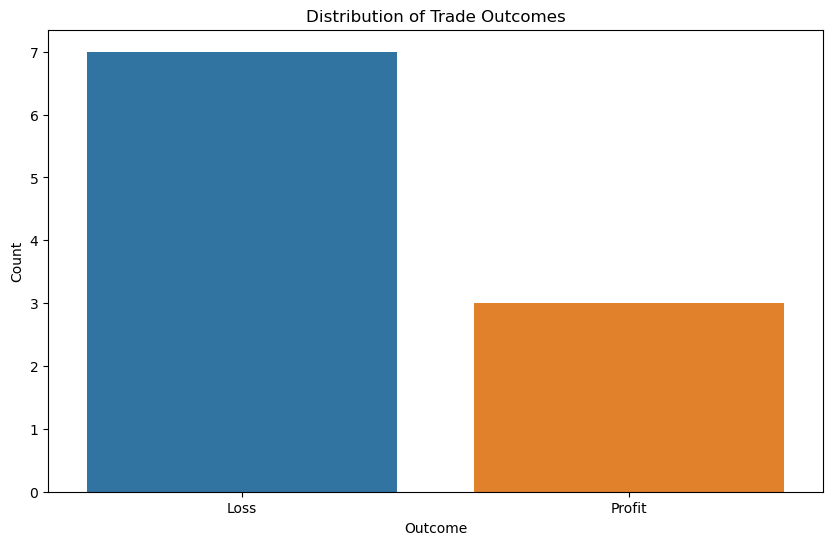

<Figure size 640x480 with 0 Axes>

In [89]:
# Convert Open_Price and Close_Price to float
df_output['Open_Price'] = df_output['Open_Price'].astype(float)
df_output['Close_Price'] = df_output['Close_Price'].astype(float)

# Distribution of Trade Outcomes
plt.figure(figsize=(10, 6))
sns.countplot(x='Outcome', data=df_output)
plt.title('Distribution of Trade Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()
plt.savefig("output/fig1.png")

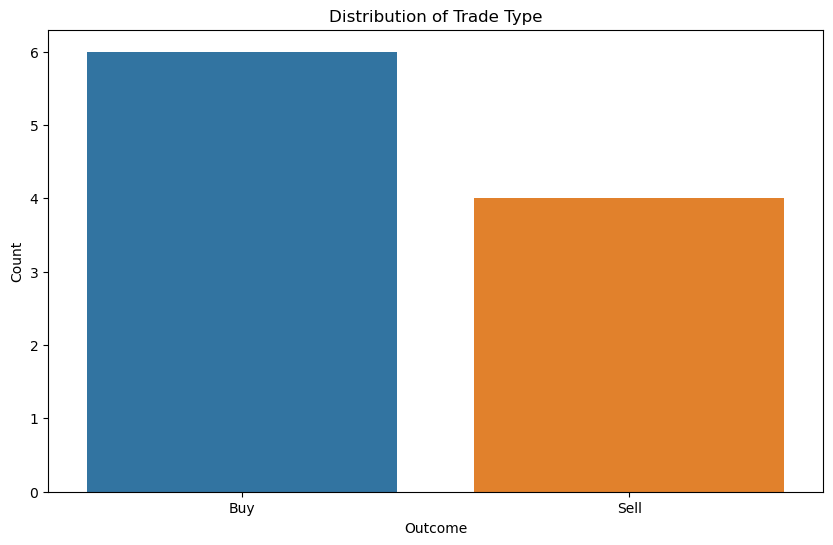

<Figure size 640x480 with 0 Axes>

In [90]:
# Convert Open_Price and Close_Price to float
df_output['Open_Price'] = df_output['Open_Price'].astype(float)
df_output['Close_Price'] = df_output['Close_Price'].astype(float)

# Distribution of Trade Outcomes
plt.figure(figsize=(10, 6))
sns.countplot(x='Order_Type', data=df_output)
plt.title('Distribution of Trade Type')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()
plt.savefig("output/fig1.png")

C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


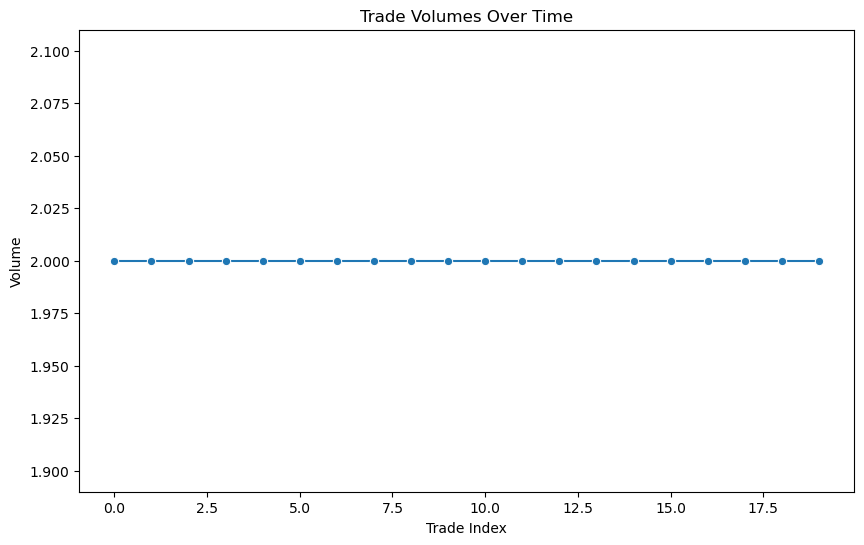

In [70]:
# Trade Volumes Over Time
plt.figure(figsize=(10, 6))
df_output['Trade_Index'] = df_output.index
sns.lineplot(x='Trade_Index', y='Margin', data=df_output, marker='o')
plt.title('Trade Volumes Over Time')
plt.xlabel('Trade Index')
plt.ylabel('Volume')
plt.show()


C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

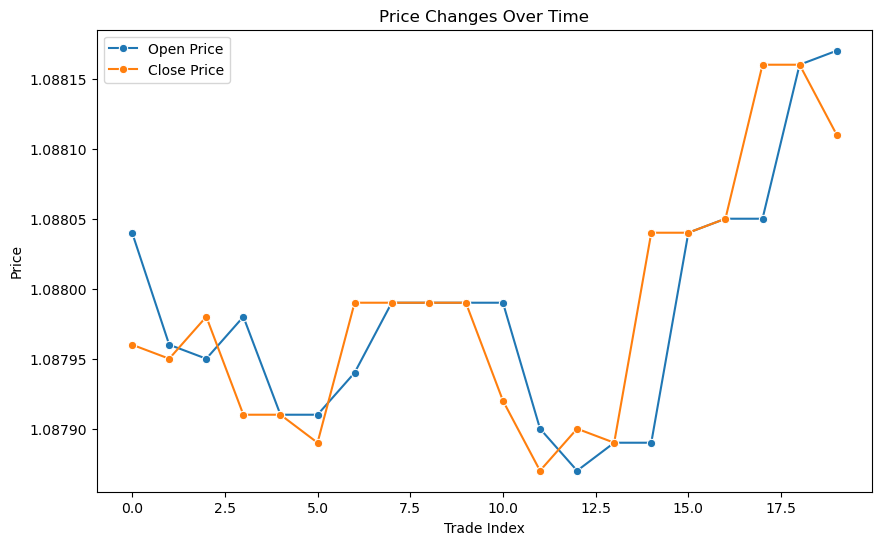

<Figure size 640x480 with 0 Axes>

In [71]:
# Price Changes (Open vs Close)
plt.figure(figsize=(10, 6))
sns.lineplot(x='Trade_Index', y='Open_Price', data=df_output, marker='o', label='Open Price')
sns.lineplot(x='Trade_Index', y='Close_Price', data=df_output, marker='o', label='Close Price')
plt.title('Price Changes Over Time')
plt.xlabel('Trade Index')
plt.ylabel('Price')
plt.legend()
plt.show()
plt.savefig("output/fig2.png")

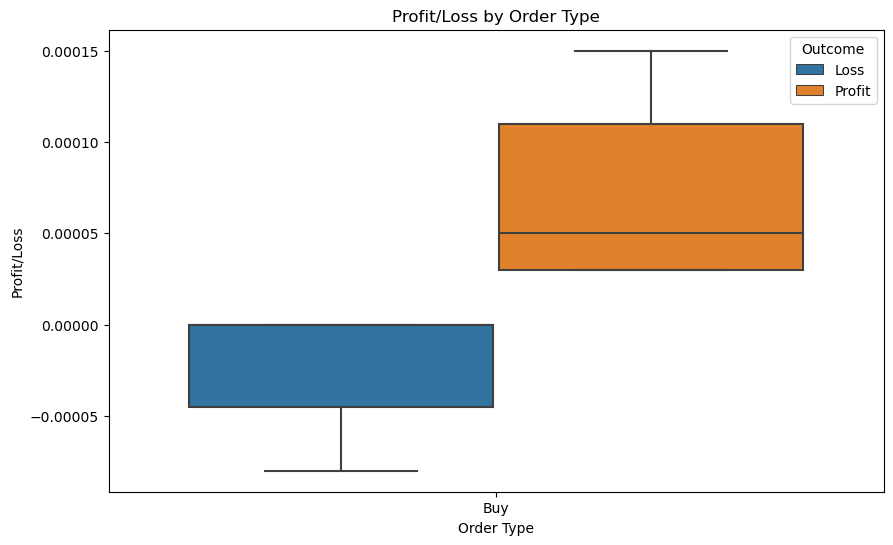

<Figure size 640x480 with 0 Axes>

In [72]:
# Profit/Loss by Order Type
df_output['Profit_Loss'] = df_output['Close_Price'] - df_output['Open_Price']
plt.figure(figsize=(10, 6))
sns.boxplot(x='Order_Type', y='Profit_Loss', hue='Outcome', data=df_output)
plt.title('Profit/Loss by Order Type')
plt.xlabel('Order Type')
plt.ylabel('Profit/Loss')
plt.show()
plt.savefig("output/fig3.png")

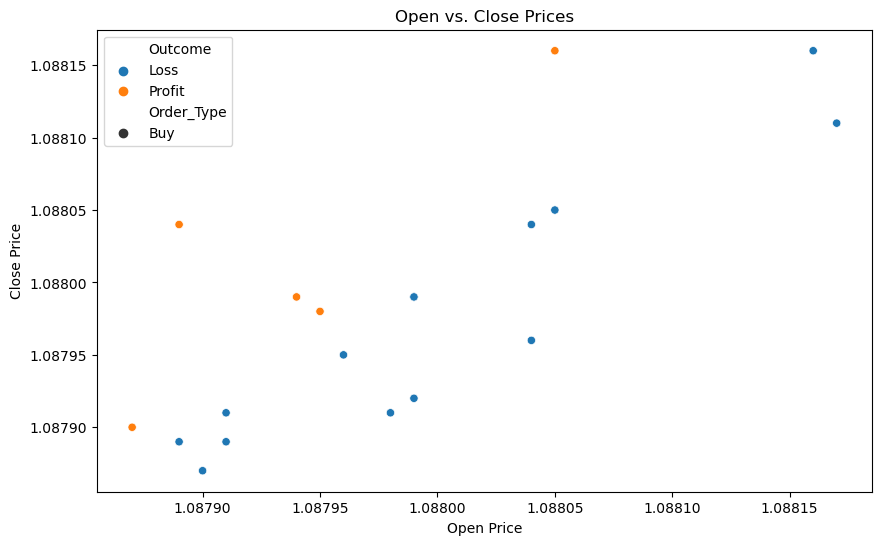

<Figure size 640x480 with 0 Axes>

In [73]:
# Scatter Plot of Open vs. Close Prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Open_Price', y='Close_Price', hue='Outcome', style='Order_Type', data=df_output)
plt.title('Open vs. Close Prices')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.legend()
plt.show()
plt.savefig("output/fig4.png")

C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


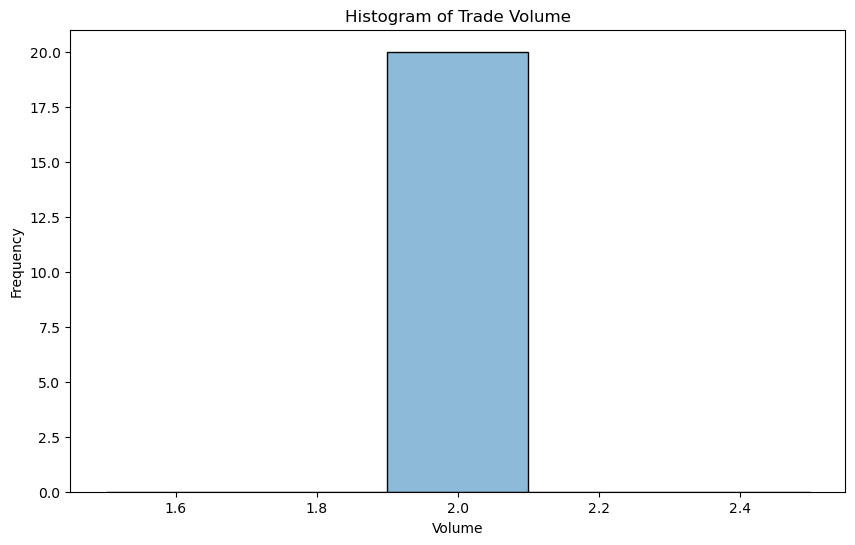

In [74]:
# Histogram of Trade Volume
plt.figure(figsize=(10, 6))
sns.histplot(df_output['Margin'], bins=5, kde=True)
plt.title('Histogram of Trade Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.show()

C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


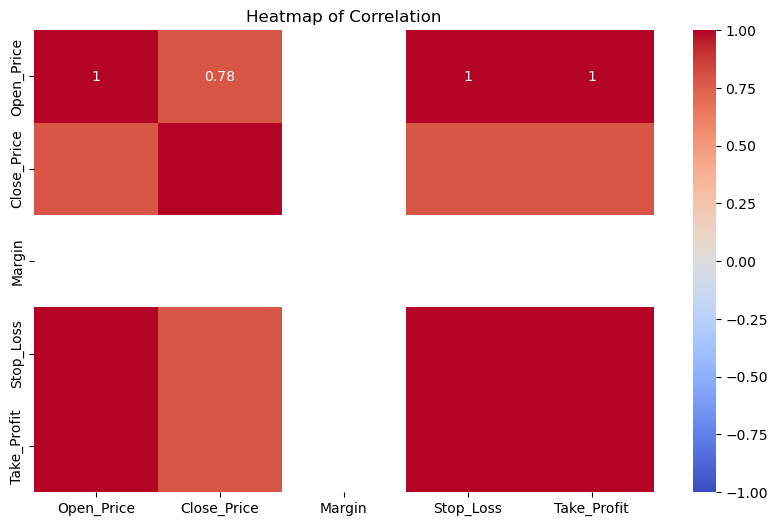

<Figure size 640x480 with 0 Axes>

In [75]:
# Heatmap of Correlation
plt.figure(figsize=(10, 6))
corr = df_output[['Open_Price', 'Close_Price', 'Margin', 'Stop_Loss', 'Take_Profit']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap of Correlation')
plt.show()
plt.savefig('output/fig5.png')

C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


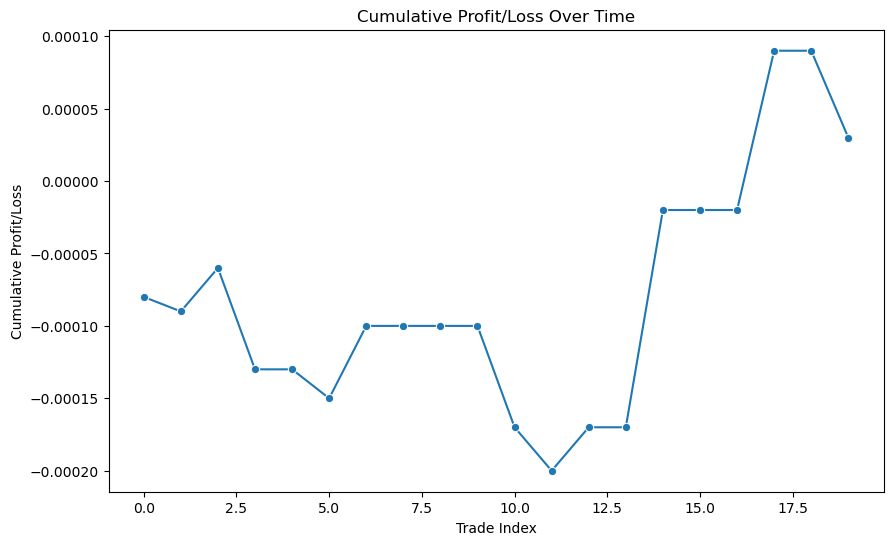

<Figure size 640x480 with 0 Axes>

In [76]:
# Cumulative Profit/Loss Over Time
df_output['Profit_Loss'] = df_output['Close_Price'] - df_output['Open_Price']
df_output['Cumulative_Profit_Loss'] = df_output['Profit_Loss'].cumsum()
plt.figure(figsize=(10, 6))
sns.lineplot(x=df_output.index, y='Cumulative_Profit_Loss', data=df_output, marker='o')
plt.title('Cumulative Profit/Loss Over Time')
plt.xlabel('Trade Index')
plt.ylabel('Cumulative Profit/Loss')
plt.show()
plt.savefig("output/fig6.png")

In [77]:
df_output.head()

,Order_Type,Volume,Open_Price,Close_Price,Stop_Loss,Take_Profit,Outcome,Profit_Loss,Trade_Open_Time,Trade_Close_Time,Duration,Prediction,Margin,Trade_Index,Cumulative_Profit_Loss
0,Buy,NaN,1.08804,1.08796,1.08799,1.08824,Loss,-0.00008,2024-10-16 11:14:29.466398,2024-10-16 11:14:59.625897,0 days 00:00:30.159499,1.0,2.0,0,-0.00008
1,Buy,NaN,1.08796,1.08795,1.08791,1.08816,Loss,-0.00001,2024-10-16 11:15:00.153961,2024-10-16 11:15:30.350148,0 days 00:00:30.196187,1.0,2.0,1,-0.00009
2,Buy,NaN,1.08795,1.08798,1.08790,1.08815,Profit,0.00003,2024-10-16 11:15:30.833392,2024-10-16 11:16:01.138592,0 days 00:00:30.305200,1.0,2.0,2,-0.00006
3,Buy,NaN,1.08798,1.08791,1.08793,1.08818,Loss,-0.00007,2024-10-16 11:16:01.585776,2024-10-16 11:16:31.734025,0 days 00:00:30.148249,1.0,2.0,3,-0.00013
4,Buy,NaN,1.08791,1.08791,1.08786,1.08811,Loss,0.00000,2024-10-16 11:16:32.235212,2024-10-16 11:17:03.206800,0 days 00:00:30.971588,1.0,2.0,4,-0.00013


In [78]:
print("Net Profit            : $%.2f" % df_output.tail(1)['Cumulative_Profit_Loss'])

Net Profit            : $0.00


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16096\2813443341.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("Net Profit            : $%.2f" % df_output.tail(1)['Cumulative_Profit_Loss'])


In [79]:
df_output.tail()

,Order_Type,Volume,Open_Price,Close_Price,Stop_Loss,Take_Profit,Outcome,Profit_Loss,Trade_Open_Time,Trade_Close_Time,Duration,Prediction,Margin,Trade_Index,Cumulative_Profit_Loss
15,Buy,NaN,1.08804,1.08804,1.08799,1.08824,Loss,0.00000,2024-10-16 11:22:12.155583,2024-10-16 11:22:42.309720,0 days 00:00:30.154137,1.0,2.0,15,-0.00002
16,Buy,NaN,1.08805,1.08805,1.08800,1.08825,Loss,0.00000,2024-10-16 11:22:42.742925,2024-10-16 11:23:12.898291,0 days 00:00:30.155366,1.0,2.0,16,-0.00002
17,Buy,NaN,1.08805,1.08816,1.08800,1.08825,Profit,0.00011,2024-10-16 11:23:13.393312,2024-10-16 11:23:43.544263,0 days 00:00:30.150951,1.0,2.0,17,0.00009
18,Buy,NaN,1.08816,1.08816,1.08811,1.08836,Loss,0.00000,2024-10-16 11:23:44.011531,2024-10-16 11:24:14.293895,0 days 00:00:30.282364,1.0,2.0,18,0.00009
19,Buy,NaN,1.08817,1.08811,1.08812,1.08837,Loss,-0.00006,2024-10-16 11:24:14.780529,2024-10-16 11:24:44.925669,0 days 00:00:30.145140,1.0,2.0,19,0.00003


In [80]:
df_output.head()

,Order_Type,Volume,Open_Price,Close_Price,Stop_Loss,Take_Profit,Outcome,Profit_Loss,Trade_Open_Time,Trade_Close_Time,Duration,Prediction,Margin,Trade_Index,Cumulative_Profit_Loss
0,Buy,NaN,1.08804,1.08796,1.08799,1.08824,Loss,-0.00008,2024-10-16 11:14:29.466398,2024-10-16 11:14:59.625897,0 days 00:00:30.159499,1.0,2.0,0,-0.00008
1,Buy,NaN,1.08796,1.08795,1.08791,1.08816,Loss,-0.00001,2024-10-16 11:15:00.153961,2024-10-16 11:15:30.350148,0 days 00:00:30.196187,1.0,2.0,1,-0.00009
2,Buy,NaN,1.08795,1.08798,1.08790,1.08815,Profit,0.00003,2024-10-16 11:15:30.833392,2024-10-16 11:16:01.138592,0 days 00:00:30.305200,1.0,2.0,2,-0.00006
3,Buy,NaN,1.08798,1.08791,1.08793,1.08818,Loss,-0.00007,2024-10-16 11:16:01.585776,2024-10-16 11:16:31.734025,0 days 00:00:30.148249,1.0,2.0,3,-0.00013
4,Buy,NaN,1.08791,1.08791,1.08786,1.08811,Loss,0.00000,2024-10-16 11:16:32.235212,2024-10-16 11:17:03.206800,0 days 00:00:30.971588,1.0,2.0,4,-0.00013


C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ADMIN\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


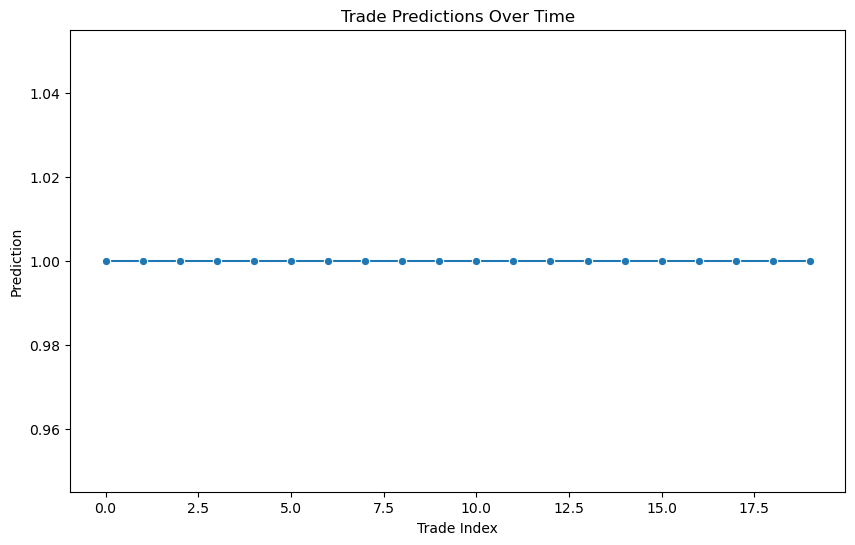

In [82]:
# Trade Volumes Over Time
plt.figure(figsize=(10, 6))
df_output['Trade_Index'] = df_output.index
sns.lineplot(x='Trade_Index', y='Prediction', data=df_output, marker='o')
plt.title('Trade Predictions Over Time')
plt.xlabel('Trade Index')
plt.ylabel('Prediction')
plt.show()
